# Global Bone Marrow Cancer Dataset — Advanced R Analysis

This notebook extends the README example with higher-level medical statistics and report-ready visualizations.

**Advanced methods used:** bootstrap coefficient stability, generalized additive models (GAM), PCA-based country phenotyping, k-means clustering, clustered heatmaps, and interrupted time-trend analysis around the modern therapy era.

All figures are saved to `analysis/advanced_figures/`; result tables are saved to `analysis/advanced_results/`.

In [1]:
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(tidyr)
  library(broom)
  library(mgcv)
  library(cluster)
  library(scales)
})

candidate_roots <- c(
  ".",
  "..",
  "example/global-bone-marrow-cancer-dataset"
)
root_dir <- candidate_roots[file.exists(file.path(candidate_roots, "data", "bone_marrow_cancer_by_country.csv"))][1]
if (is.na(root_dir)) stop("Cannot locate the global bone marrow cancer dataset root directory.")

data_dir <- file.path(root_dir, "data")
fig_dir <- file.path(root_dir, "analysis", "advanced_figures")
result_dir <- file.path(root_dir, "analysis", "advanced_results")
dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(result_dir, recursive = TRUE, showWarnings = FALSE)

save_plot <- function(filename, plot, width = 10, height = 7, dpi = 320) {
  ggsave(file.path(fig_dir, filename), plot = plot, width = width, height = height, dpi = dpi, bg = "white")
}

base_theme <- theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(face = "bold", size = 16),
    plot.subtitle = element_text(color = "grey35"),
    panel.grid.minor = element_blank(),
    legend.position = "bottom"
  )

continent_palette <- c(
  Africa = "#D55E00",
  Americas = "#0072B2",
  Asia = "#009E73",
  Europe = "#CC79A7",
  Oceania = "#E69F00"
)

## 1. Data preparation and derived health-system indicators

The country-level data are enriched with case-fatality ratios, BMT centers per population, and standardized predictors. These derived variables make the later models easier to interpret clinically.

In [2]:
country <- read.csv(file.path(data_dir, "bone_marrow_cancer_by_country.csv")) %>%
  mutate(
    Continent = factor(Continent),
    log_population = log(Population_M),
    BMT_Centers_per_10M = BMT_Centers / Population_M * 10,
    Myeloma_Case_Fatality = Myeloma_Deaths / Myeloma_New_Cases,
    Leukemia_Case_Fatality = Leukemia_Deaths / Leukemia_New_Cases,
    z_BMT_Access = as.numeric(scale(BMT_Access_Score)),
    z_Hematologists = as.numeric(scale(Hematologists_Per_Million)),
    z_Myeloma_Incidence = as.numeric(scale(Myeloma_Incidence_Per_100K)),
    z_Leukemia_Incidence = as.numeric(scale(Leukemia_Incidence_Per_100K)),
    z_log_population = as.numeric(scale(log_population)),
    z_BMT_Centers_per_10M = as.numeric(scale(BMT_Centers_per_10M))
  )

trends <- read.csv(file.path(data_dir, "bone_marrow_cancer_trends_2000_2026.csv")) %>%
  mutate(
    Year = as.numeric(Year),
    therapy_era = ifelse(Year >= 2010, "Modern therapy era", "Early targeted therapy era"),
    Myeloma_Case_Fatality = Global_Myeloma_Deaths / Global_Myeloma_New_Cases,
    Leukemia_Case_Fatality = Global_Leukemia_Deaths / Global_Leukemia_New_Cases
  )

survival <- read.csv(file.path(data_dir, "bone_marrow_cancer_survival.csv"))

glimpse(country)

Rows: 50
Columns: 25
$ Country                     <chr> "United States", "China", "India", "Japan"…
$ Region                      <chr> "North America", "East Asia", "South Asia"…
$ Continent                   <fct> Americas, Asia, Asia, Asia, Europe, Europe…
$ Population_M                <dbl> 331.9, 1412.0, 1408.0, 125.7, 83.2, 67.3, …
$ Myeloma_New_Cases           <int> 35780, 20100, 14200, 7800, 6700, 5900, 550…
$ Leukemia_New_Cases          <int> 59610, 75000, 42000, 14200, 15200, 10300, …
$ Myeloma_Deaths              <int> 12590, 14500, 11800, 4200, 3100, 3100, 300…
$ Leukemia_Deaths             <int> 23710, 51500, 35000, 8800, 7600, 4900, 550…
$ Myeloma_Incidence_Per_100K  <dbl> 7.2, 1.6, 1.2, 6.0, 7.5, 9.3, 8.4, 3.8, 9.…
$ Leukemia_Incidence_Per_100K <dbl> 14.2, 5.5, 3.3, 10.6, 13.8, 14.0, 14.6, 5.…
$ Myeloma_5Y_Survival_Pct     <dbl> 59.8, 42.0, 28.0, 48.0, 55.0, 52.0, 54.0, …
$ Leukemia_5Y_Survival_Pct    <dbl> 65, 38, 25, 58, 62, 60, 61, 40, 60, 63, 62…
$ BMT_Centers      

## 2. Bootstrap multivariable regression stability

A single multivariable regression can be unstable with 50 country-level observations. This section bootstraps standardized coefficients to show which associations remain directionally stable under resampling.

Warning message:
“`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead.”
`height` was translated to `width`.
`height` was translated to `width`.


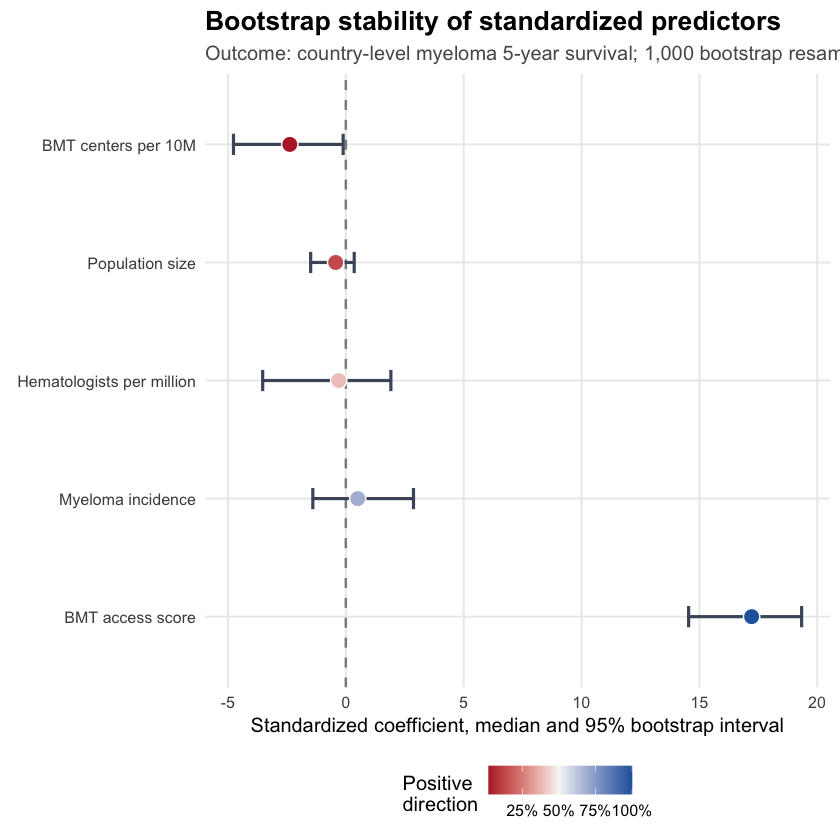

In [3]:
set.seed(20260602)
model_formula <- Myeloma_5Y_Survival_Pct ~ z_BMT_Access + z_Hematologists +
  z_Myeloma_Incidence + z_log_population + z_BMT_Centers_per_10M

fit_lm <- lm(model_formula, data = country)
coef_terms <- names(coef(fit_lm))[-1]

boot_n <- 1000
boot_coef <- replicate(boot_n, {
  idx <- sample(seq_len(nrow(country)), replace = TRUE)
  fit <- lm(model_formula, data = country[idx, ])
  coef(fit)[coef_terms]
})

boot_summary <- as.data.frame(t(boot_coef)) %>%
  pivot_longer(everything(), names_to = "term", values_to = "estimate") %>%
  group_by(term) %>%
  summarise(
    median = median(estimate, na.rm = TRUE),
    conf.low = quantile(estimate, 0.025, na.rm = TRUE),
    conf.high = quantile(estimate, 0.975, na.rm = TRUE),
    p_direction_positive = mean(estimate > 0, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  mutate(
    term_label = recode(term,
      z_BMT_Access = "BMT access score",
      z_Hematologists = "Hematologists per million",
      z_Myeloma_Incidence = "Myeloma incidence",
      z_log_population = "Population size",
      z_BMT_Centers_per_10M = "BMT centers per 10M"
    ),
    term_label = factor(term_label, levels = rev(term_label[order(median)]))
  )

write.csv(boot_summary, file.path(result_dir, "bootstrap_standardized_coefficients.csv"), row.names = FALSE)

p_boot <- ggplot(boot_summary, aes(x = median, y = term_label)) +
  geom_vline(xintercept = 0, linewidth = 0.7, linetype = "dashed", color = "grey55") +
  geom_errorbarh(aes(xmin = conf.low, xmax = conf.high), height = 0.18, linewidth = 0.9, color = "#4C566A") +
  geom_point(aes(fill = p_direction_positive), shape = 21, size = 4.2, color = "white", stroke = 0.6) +
  scale_fill_gradient2(low = "#B2182B", mid = "#F7F7F7", high = "#2166AC", midpoint = 0.5,
                       labels = percent_format(accuracy = 1), name = "Positive\ndirection") +
  labs(
    title = "Bootstrap stability of standardized predictors",
    subtitle = "Outcome: country-level myeloma 5-year survival; 1,000 bootstrap resamples",
    x = "Standardized coefficient, median and 95% bootstrap interval",
    y = NULL
  ) +
  base_theme

save_plot("advanced_bootstrap_forest.png", p_boot, width = 10, height = 6.5)
p_boot

## 3. Nonlinear health-system access effect with GAM

The GAM checks whether the relationship between BMT access and 5-year survival is approximately linear or whether the survival gain changes across the access gradient.

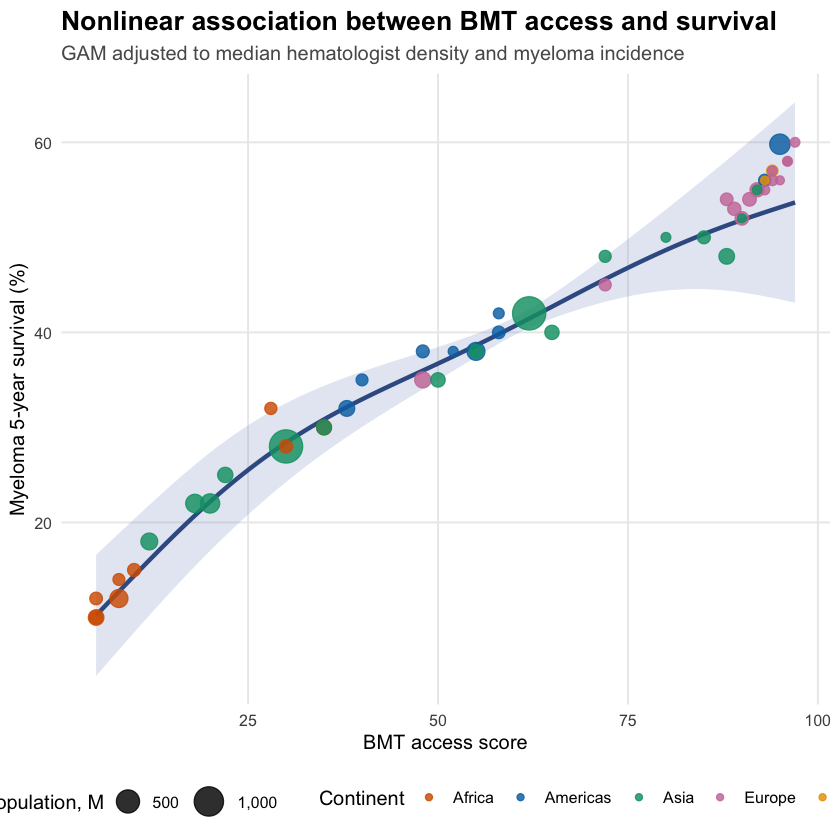

In [4]:
gam_fit <- gam(
  Myeloma_5Y_Survival_Pct ~
    s(BMT_Access_Score, k = 5) +
    s(Hematologists_Per_Million, k = 5) +
    s(Myeloma_Incidence_Per_100K, k = 5),
  data = country,
  method = "REML"
)

gam_grid <- data.frame(
  BMT_Access_Score = seq(min(country$BMT_Access_Score), max(country$BMT_Access_Score), length.out = 200),
  Hematologists_Per_Million = median(country$Hematologists_Per_Million),
  Myeloma_Incidence_Per_100K = median(country$Myeloma_Incidence_Per_100K)
)

gam_pred <- predict(gam_fit, newdata = gam_grid, se.fit = TRUE)
gam_grid <- gam_grid %>%
  mutate(
    fitted = gam_pred$fit,
    conf.low = fitted - 1.96 * gam_pred$se.fit,
    conf.high = fitted + 1.96 * gam_pred$se.fit
  )

write.csv(tidy(gam_fit), file.path(result_dir, "gam_smooth_terms.csv"), row.names = FALSE)

p_gam <- ggplot(country, aes(BMT_Access_Score, Myeloma_5Y_Survival_Pct)) +
  geom_ribbon(data = gam_grid, aes(x = BMT_Access_Score, ymin = conf.low, ymax = conf.high, y = fitted),
              inherit.aes = FALSE, fill = "#8DA0CB", alpha = 0.24) +
  geom_line(data = gam_grid, aes(x = BMT_Access_Score, y = fitted), inherit.aes = FALSE,
            color = "#3B5B92", linewidth = 1.25) +
  geom_point(aes(color = Continent, size = Population_M), alpha = 0.82) +
  scale_color_manual(values = continent_palette) +
  scale_size_continuous(range = c(2, 9), labels = comma, name = "Population, M") +
  labs(
    title = "Nonlinear association between BMT access and survival",
    subtitle = "GAM adjusted to median hematologist density and myeloma incidence",
    x = "BMT access score",
    y = "Myeloma 5-year survival (%)",
    color = "Continent"
  ) +
  base_theme

save_plot("advanced_gam_bmt_survival.png", p_gam, width = 10.5, height = 7)
p_gam

## 4. PCA-based country phenotypes and clustered heatmap

Instead of showing PCA alone, this section uses the leading PCA dimensions as a lower-dimensional health-system phenotype space, then clusters countries into interpretable profiles.

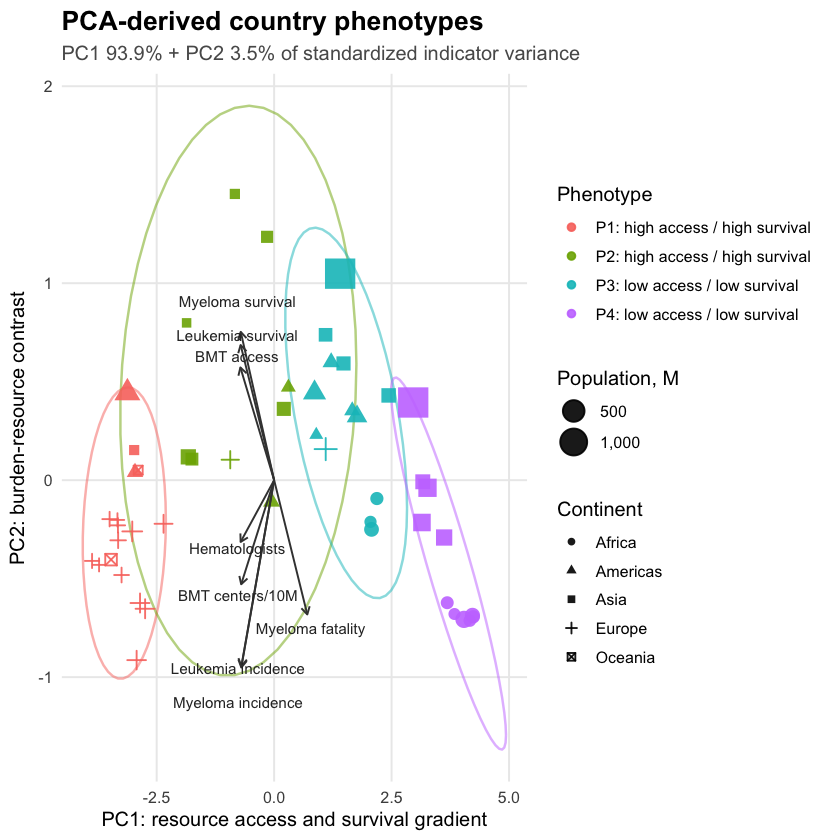

In [5]:
feature_labels <- c(
  Myeloma_Incidence_Per_100K = "Myeloma incidence",
  Leukemia_Incidence_Per_100K = "Leukemia incidence",
  Myeloma_5Y_Survival_Pct = "Myeloma survival",
  Leukemia_5Y_Survival_Pct = "Leukemia survival",
  BMT_Access_Score = "BMT access",
  Hematologists_Per_Million = "Hematologists",
  BMT_Centers_per_10M = "BMT centers/10M",
  Myeloma_Case_Fatality = "Myeloma fatality"
)
feature_vars <- names(feature_labels)

feature_mat <- country[, feature_vars]
row.names(feature_mat) <- country$Country
feature_scaled <- scale(feature_mat)

pca <- prcomp(feature_scaled, center = FALSE, scale. = FALSE)
pca_var <- pca$sdev^2 / sum(pca$sdev^2)

set.seed(20260602)
km <- kmeans(pca$x[, 1:3], centers = 4, nstart = 50)
country$Phenotype <- factor(km$cluster)

phenotype_profile <- country %>%
  group_by(Phenotype) %>%
  summarise(
    n = n(),
    median_survival = median(Myeloma_5Y_Survival_Pct),
    median_bmt_access = median(BMT_Access_Score),
    median_hematologists = median(Hematologists_Per_Million),
    median_case_fatality = median(Myeloma_Case_Fatality),
    .groups = "drop"
  ) %>%
  arrange(desc(median_survival), desc(median_bmt_access)) %>%
  mutate(Phenotype_Label = paste0("P", row_number(), ": ", case_when(
    median_bmt_access >= median(country$BMT_Access_Score) & median_survival >= median(country$Myeloma_5Y_Survival_Pct) ~ "high access / high survival",
    median_bmt_access < median(country$BMT_Access_Score) & median_survival < median(country$Myeloma_5Y_Survival_Pct) ~ "low access / low survival",
    median_bmt_access >= median(country$BMT_Access_Score) ~ "resource-rich mixed survival",
    TRUE ~ "resource-constrained mixed survival"
  )))

label_map <- setNames(phenotype_profile$Phenotype_Label, phenotype_profile$Phenotype)
country$Phenotype_Label <- factor(label_map[as.character(country$Phenotype)], levels = phenotype_profile$Phenotype_Label)

country_scores <- as.data.frame(pca$x[, 1:3]) %>%
  mutate(
    Country = country$Country,
    Continent = country$Continent,
    Population_M = country$Population_M,
    Phenotype_Label = country$Phenotype_Label
  )

loadings <- as.data.frame(pca$rotation[, 1:2]) %>%
  mutate(variable = feature_labels[row.names(.)])
arrow_scale <- min(
  diff(range(country_scores$PC1)) / diff(range(loadings$PC1)),
  diff(range(country_scores$PC2)) / diff(range(loadings$PC2))
) * 0.72
loadings <- loadings %>%
  mutate(
    PC1 = PC1 * arrow_scale,
    PC2 = PC2 * arrow_scale,
    label_x = PC1 * 1.10,
    label_y = PC2 * 1.10 + case_when(
      variable == "Myeloma incidence" ~ -0.09,
      variable == "Leukemia incidence" ~ 0.09,
      variable == "Myeloma survival" ~ 0.08,
      variable == "Leukemia survival" ~ -0.02,
      TRUE ~ 0
    )
  )

write.csv(country %>% select(Country, Region, Continent, Phenotype_Label, all_of(feature_vars)),
          file.path(result_dir, "country_pca_phenotypes.csv"), row.names = FALSE)
write.csv(phenotype_profile, file.path(result_dir, "phenotype_cluster_profiles.csv"), row.names = FALSE)

p_pca <- ggplot(country_scores, aes(PC1, PC2)) +
  stat_ellipse(aes(color = Phenotype_Label), linewidth = 0.7, alpha = 0.5, show.legend = FALSE) +
  geom_point(aes(color = Phenotype_Label, shape = Continent, size = Population_M),
             stroke = 0.8, alpha = 0.9) +
  geom_segment(data = loadings, aes(x = 0, y = 0, xend = PC1, yend = PC2),
               inherit.aes = FALSE, arrow = arrow(length = unit(0.18, "cm")),
               color = "grey25", linewidth = 0.55) +
  geom_text(data = loadings, aes(x = label_x, y = label_y, label = variable),
            inherit.aes = FALSE, size = 3.2, color = "grey18", check_overlap = TRUE) +
  scale_size_continuous(range = c(2, 8), labels = comma, name = "Population, M") +
  labs(
    title = "PCA-derived country phenotypes",
    subtitle = sprintf("PC1 %.1f%% + PC2 %.1f%% of standardized indicator variance", pca_var[1] * 100, pca_var[2] * 100),
    x = "PC1: resource access and survival gradient",
    y = "PC2: burden-resource contrast",
    color = "Phenotype",
    shape = "Continent"
  ) +
  base_theme +
  theme(legend.position = "right") +
  guides(color = guide_legend(ncol = 1), shape = guide_legend(ncol = 1), size = guide_legend(ncol = 1))

save_plot("advanced_pca_country_phenotypes.png", p_pca, width = 13, height = 8)
p_pca

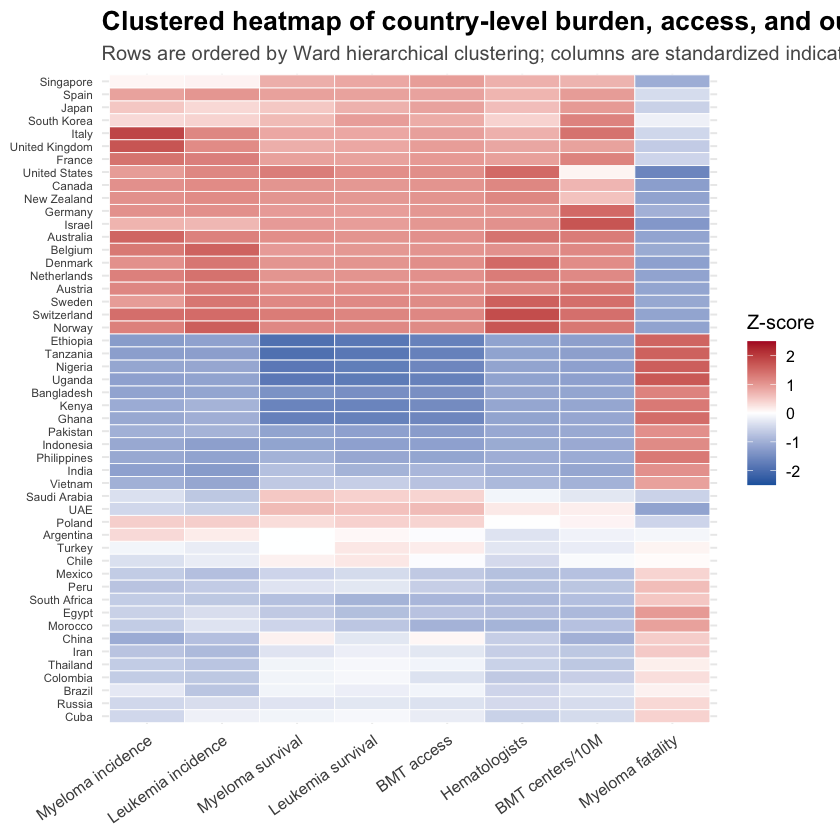

In [6]:
hc <- hclust(dist(feature_scaled), method = "ward.D2")
ordered_countries <- row.names(feature_scaled)[hc$order]

heatmap_df <- as.data.frame(feature_scaled) %>%
  mutate(Country = row.names(feature_scaled)) %>%
  pivot_longer(-Country, names_to = "indicator", values_to = "z_score") %>%
  mutate(
    Country = factor(Country, levels = rev(ordered_countries)),
    indicator = factor(feature_labels[indicator], levels = feature_labels)
  )

p_heat <- ggplot(heatmap_df, aes(indicator, Country, fill = z_score)) +
  geom_tile(color = "white", linewidth = 0.25) +
  scale_fill_gradient2(low = "#2166AC", mid = "white", high = "#B2182B", midpoint = 0,
                       limits = c(-2.5, 2.5), oob = squish, name = "Z-score") +
  labs(
    title = "Clustered heatmap of country-level burden, access, and outcome indicators",
    subtitle = "Rows are ordered by Ward hierarchical clustering; columns are standardized indicators",
    x = NULL,
    y = NULL
  ) +
  base_theme +
  theme(
    axis.text.x = element_text(angle = 35, hjust = 1),
    axis.text.y = element_text(size = 7),
    legend.position = "right"
  )

save_plot("advanced_clustered_indicator_heatmap.png", p_heat, width = 12.5, height = 12)
p_heat

## 5. Therapy-era time trends and survival trajectories

The global trends are visualized with nonlinear smooths and treatment milestones. A simple interrupted-trend model compares the annual survival slope before and after 2010 as a pragmatic marker of the modern therapy era.

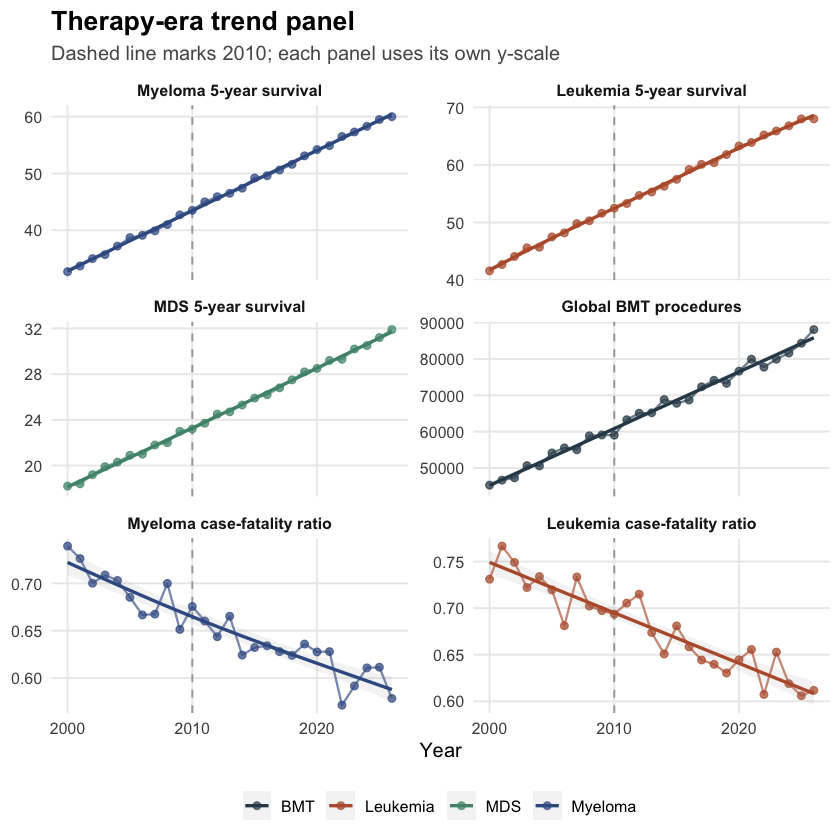

In [7]:
surv_long <- trends %>%
  select(Year, Myeloma_5Y_Survival_Pct, Leukemia_5Y_Survival_Pct, MDS_5Y_Survival_Pct) %>%
  pivot_longer(-Year, names_to = "Cancer", values_to = "Survival") %>%
  mutate(Cancer = recode(Cancer,
    Myeloma_5Y_Survival_Pct = "Myeloma",
    Leukemia_5Y_Survival_Pct = "Leukemia",
    MDS_5Y_Survival_Pct = "MDS"
  ))

trend_models <- surv_long %>%
  group_by(Cancer) %>%
  group_modify(~ {
    dat <- .x %>% mutate(
      Year_c = Year - 2000,
      post_2010 = as.integer(Year >= 2010),
      after_2010 = pmax(Year - 2010, 0)
    )
    tidy(lm(Survival ~ Year_c + post_2010 + after_2010, data = dat))
  }) %>%
  ungroup()
write.csv(trend_models, file.path(result_dir, "interrupted_survival_trend_models.csv"), row.names = FALSE)

milestones <- trends %>%
  filter(Key_Milestone != "" & !is.na(Key_Milestone)) %>%
  filter(Year %in% c(2001, 2003, 2015, 2021)) %>%
  mutate(label = paste0(Year, ": ", sub(" —.*", "", Key_Milestone)))

p_surv_trend <- ggplot(surv_long, aes(Year, Survival, color = Cancer)) +
  geom_vline(data = milestones, aes(xintercept = Year), inherit.aes = FALSE,
             linetype = "dotted", color = "grey55") +
  geom_point(size = 2.2, alpha = 0.78) +
  geom_line(linewidth = 0.75, alpha = 0.55) +
  geom_smooth(method = "gam", formula = y ~ s(x, k = 5), se = TRUE, linewidth = 1.1, alpha = 0.12) +
  annotate("text", x = milestones$Year, y = max(surv_long$Survival) + 2.2,
           label = milestones$label, angle = 90, hjust = 1, size = 3, color = "grey25") +
  scale_color_manual(values = c(Myeloma = "#3B5B92", Leukemia = "#B85C38", MDS = "#4E937A")) +
  coord_cartesian(ylim = c(min(surv_long$Survival) - 1, max(surv_long$Survival) + 7), clip = "off") +
  labs(
    title = "Nonlinear survival gains across therapy eras",
    subtitle = "GAM smooths with selected milestones from the dataset annotation",
    x = "Year",
    y = "5-year survival (%)",
    color = "Cancer type"
  ) +
  base_theme +
  theme(plot.margin = margin(10, 20, 10, 10))

save_plot("advanced_survival_milestone_trends.png", p_surv_trend, width = 13, height = 7.5)

trend_panel_df <- bind_rows(
  surv_long %>% transmute(Year, Metric = paste0(Cancer, " 5-year survival"), Value = Survival, Group = Cancer),
  trends %>% transmute(Year, Metric = "Global BMT procedures", Value = Global_BMT_Procedures, Group = "BMT"),
  trends %>% transmute(Year, Metric = "Myeloma case-fatality ratio", Value = Myeloma_Case_Fatality, Group = "Myeloma"),
  trends %>% transmute(Year, Metric = "Leukemia case-fatality ratio", Value = Leukemia_Case_Fatality, Group = "Leukemia")
) %>%
  mutate(Metric = factor(Metric, levels = c(
    "Myeloma 5-year survival", "Leukemia 5-year survival", "MDS 5-year survival",
    "Global BMT procedures", "Myeloma case-fatality ratio", "Leukemia case-fatality ratio"
  )))

p_trend_panel <- ggplot(trend_panel_df, aes(Year, Value, color = Group)) +
  geom_vline(xintercept = 2010, linetype = "dashed", color = "grey65") +
  geom_point(size = 1.8, alpha = 0.72) +
  geom_line(linewidth = 0.65, alpha = 0.65) +
  geom_smooth(method = "gam", formula = y ~ s(x, k = 5), se = TRUE, linewidth = 0.95, alpha = 0.11) +
  facet_wrap(~ Metric, scales = "free_y", ncol = 2) +
  scale_color_manual(values = c(Myeloma = "#3B5B92", Leukemia = "#B85C38", MDS = "#4E937A", BMT = "#2F4858")) +
  labs(
    title = "Therapy-era trend panel",
    subtitle = "Dashed line marks 2010; each panel uses its own y-scale",
    x = "Year",
    y = NULL,
    color = NULL
  ) +
  base_theme +
  theme(strip.text = element_text(face = "bold"))

save_plot("advanced_therapy_era_trends.png", p_trend_panel, width = 13, height = 10)
p_trend_panel

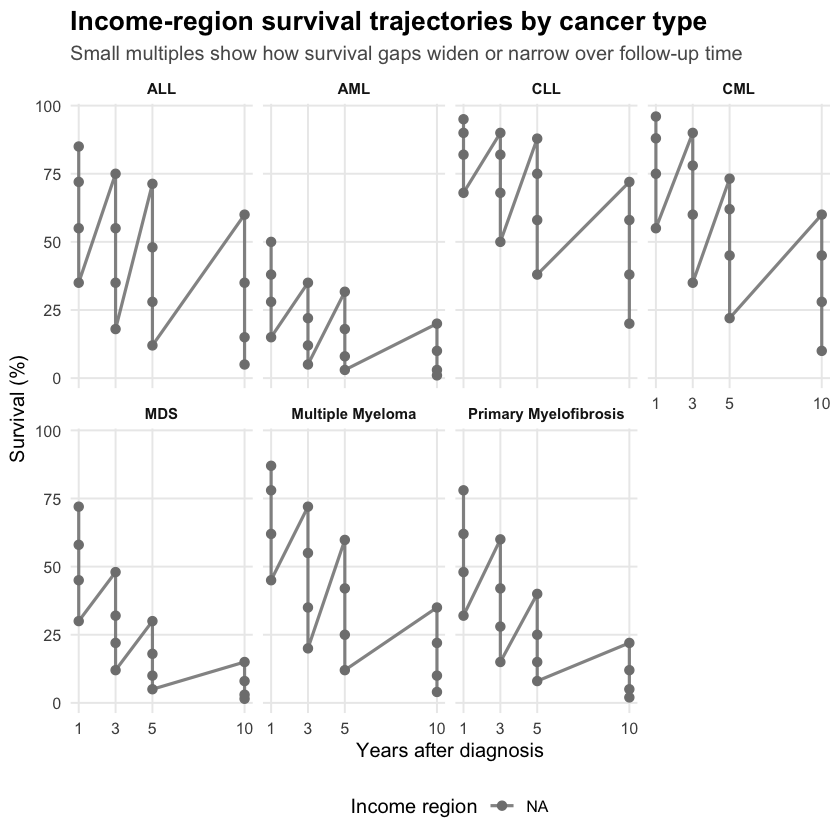

In [8]:
surv_trajectory <- survival %>%
  pivot_longer(
    cols = c(One_Year_Survival_Pct, Three_Year_Survival_Pct, Five_Year_Survival_Pct, Ten_Year_Survival_Pct),
    names_to = "Timepoint",
    values_to = "Survival"
  ) %>%
  mutate(
    Time_Years = recode(Timepoint,
      One_Year_Survival_Pct = 1,
      Three_Year_Survival_Pct = 3,
      Five_Year_Survival_Pct = 5,
      Ten_Year_Survival_Pct = 10
    ),
    Income_Region = factor(Income_Region, levels = c("Low Income", "Lower-Middle Income", "Upper-Middle Income", "High Income"))
  )

p_trajectory <- ggplot(surv_trajectory, aes(Time_Years, Survival, color = Income_Region)) +
  geom_line(linewidth = 0.9, alpha = 0.85) +
  geom_point(size = 2.2) +
  facet_wrap(~ Cancer_Type, ncol = 4) +
  scale_x_continuous(breaks = c(1, 3, 5, 10)) +
  scale_color_manual(values = c(
    "Low Income" = "#B2182B",
    "Lower-Middle Income" = "#EF8A62",
    "Upper-Middle Income" = "#67A9CF",
    "High Income" = "#2166AC"
  )) +
  labs(
    title = "Income-region survival trajectories by cancer type",
    subtitle = "Small multiples show how survival gaps widen or narrow over follow-up time",
    x = "Years after diagnosis",
    y = "Survival (%)",
    color = "Income region"
  ) +
  base_theme +
  theme(strip.text = element_text(face = "bold", size = 9))

save_plot("advanced_income_survival_trajectories.png", p_trajectory, width = 13, height = 7.5)
p_trajectory

## 6. Outputs

The notebook writes the following key artifacts:

- `advanced_figures/advanced_bootstrap_forest.png`
- `advanced_figures/advanced_gam_bmt_survival.png`
- `advanced_figures/advanced_pca_country_phenotypes.png`
- `advanced_figures/advanced_clustered_indicator_heatmap.png`
- `advanced_figures/advanced_therapy_era_trends.png`
- `advanced_figures/advanced_income_survival_trajectories.png`
- `advanced_results/bootstrap_standardized_coefficients.csv`
- `advanced_results/gam_smooth_terms.csv`
- `advanced_results/country_pca_phenotypes.csv`
- `advanced_results/phenotype_cluster_profiles.csv`
- `advanced_results/interrupted_survival_trend_models.csv`